**Kualitas Udara Antar Negara Tahun 2023**

* **Kelompok: Kelompok 14**
* **Nama dan NRP:**
    1. [Dennis Immanuel Stevano Baskoro] - [5027261096]
    2. [Eric Fahrezi Hutagalung] - [5027261138]
    3. [Fikri Taqiyuddin Althaf] - [5027261077]
* **Topik:** Eksplorasi Data tentang Kualitas Udara Antar Negara Tahun 2023.

**Latar Belakang dan Pertanyaan**


Data ini menarik karena memperlihatkan kontras polusi dan cuaca di kota-kota lintas benua. Terlihat dinamika unik antarwilayah, seperti Rio de Janeiro yang memiliki PM2.5 dan O3 tinggi pada kelembapan rendah (29,30%), berbanding terbalik dengan Mumbai yang mencatatkan PM10 tertinggi pada kelembapan ekstrem (99,97%).


Pertanyaan: 
1. Berapa rata-rata, median, dan seberapa besar variasi (standar deviasi) tingkat PM2.5 di setiap kota?
2. Apakah kota dengan rata-rata kelembapan udara tinggi cenderung memiliki kadar PM10 dan NO2 yang lebih rendah dibanding kota bernilai kelembapan rendah?
3. Jenis polutan mana (PM2.5, PM10, NO2, SO2, CO, atau O3) yang memiliki rentang dan persebaran nilai paling bervariasi secara global?

In [40]:
import pandas as pd

df = pd.read_csv("global_air_quality_data_10000.csv")
print(df.shape)   # (jumlah baris, jumlah kolom)
df.head()

(10000, 12)


,City,Country,Date,PM2.5,PM10,NO2,SO2,CO,O3,Temperature,Humidity,Wind Speed
0,Bangkok,Thailand,2023-03-19,86.57,25.19,99.88,30.63,4.46,36.29,17.67,59.35,13.76
1,Istanbul,Turkey,2023-02-16,50.63,97.39,48.14,8.71,3.40,144.16,3.46,67.51,6.36
2,Rio de Janeiro,Brazil,2023-11-13,130.21,57.22,98.51,9.92,0.12,179.31,25.29,29.30,12.87
3,Mumbai,India,2023-03-16,119.70,130.52,10.96,33.03,7.74,38.65,23.15,99.97,7.71
4,Paris,France,2023-04-04,55.20,36.62,76.85,21.85,2.00,67.09,16.02,90.28,14.16


**Deskripsi Data**

* Sumber data dan lisensi: (https://www.kaggle.com/datasets/waqi786/global-air-quality-dataset), dengan lisensi Apache 2.0.
* Pengumpulan data: oleh Waqar Ali, data kualitas udara ini dikumpulkan dari beberapa stasiun pemantauan resmi yang berlokasi di masing-masing kota. Pengukuran dicatat secara berkala dan dikompilasi untuk membentuk himpunan data (dataset) komprehensif yang mencakup berbagai polutan serta faktor lingkungan. Data tersebut kemudian dibersihkan dan diformat untuk memastikan siap digunakan untuk analisis. Data tersebut dikumpulkan dari berbagai sumber terpercaya, termasuk lembaga lingkungan hidup pemerintah dan organisasi internasional yang berfokus pada pemantauan kualitas udara. Data ini telah diagregasi dan diproses untuk memastikan konsistensi serta akurasinya. 
* Jumlah baris dan kolom: 10.000 baris dan 12 kolom.

**Kamus Data**

| Kolom | Arti | Jenis variabel | Skala | Satuan | Contoh |
| --- | --- | --- | --- | --- | --- |
| **City** | Nama kota lokasi pengukuran | Kualitatif | Nominal | - | Bangkok |
| **Country** | Nama negara lokasi kota berada | Kualitatif | Nominal | - | Thailand |
| **Date** | Tanggal waktu perekaman data | Kuantitatif kontinu | Interval | YYYY-MM-DD | 2023-03-19 |
| **PM2.5** | Konsentrasi partikel halus (<= 2.5 µm) di udara | Kuantitatif kontinu | Rasio | µg/m³ | 86.57 |
| **PM10** | Konsentrasi partikel kasar (<= 10 µm) di udara | Kuantitatif kontinu | Rasio | µg/m³ | 25.19 |
| **NO2** | Konsentrasi gas Nitrogen Dioksida di udara | Kuantitatif kontinu | Rasio | µg/m³ | 99.88 |
| **SO2** | Konsentrasi gas Sulfur Dioksida di udara | Kuantitatif kontinu | Rasio | µg/m³ | 30.63 |
| **CO** | Konsentrasi gas Karbon Monoksida di udara | Kuantitatif kontinu | Rasio | mg/m³ | 4.46 |
| **O3** | Konsentrasi gas Ozon Permukaan di udara | Kuantitatif kontinu | Rasio | µg/m³ | 36.29 |
| **Temperature** | Suhu udara saat pengukuran | Kuantitatif kontinu | Interval | °C | 17.67 |
| **Humidity** | Kelembapan relatif udara saat pengukuran | Kuantitatif kontinu | Rasio | % | 59.35 |
| **Wind Speed** | Kecepatan angin saat pengukuran | Kuantitatif kontinu | Rasio | m/s | 13.76 |

**Temperature, Humidity, dan Wind Speed**

In [21]:
cuaca = ["Temperature", "Humidity", "Wind Speed"]
df[cuaca].isna().sum().to_frame("jumlah_missing")


,jumlah_missing
Temperature,0
Humidity,0
Wind Speed,0


**Temperature**

In [22]:
df["Temperature"].describe().round(2).to_frame().T


,count,mean,std,min,25%,50%,75%,max
Temperature,10000.0,14.9,14.44,-10.0,2.26,14.76,27.38,40.0


In [41]:
temp_kota = df.groupby("City")["Temperature"].agg(["mean", "median", "std", "min", "max"]).round(2)
temp_kota.sort_values("mean", ascending=False)

,mean,median,std,min,max
City,,,,,
Rio de Janeiro,16.19,16.87,14.32,-9.46,39.81
London,15.76,15.76,14.88,-9.57,39.94
Moscow,15.51,15.55,14.57,-9.76,39.98
Mexico City,15.41,15.66,14.35,-9.97,39.76
Madrid,15.38,16.41,14.42,-9.95,39.99
Seoul,15.27,14.50,14.91,-9.97,39.91
Istanbul,15.20,14.22,14.43,-9.97,40.00
Toronto,15.15,14.46,14.13,-9.95,39.82
Berlin,15.03,16.01,14.37,-9.81,40.00


**Humidity (Kelembaban)**

In [24]:
df["Humidity"].describe().round(2).to_frame().T


,count,mean,std,min,25%,50%,75%,max
Humidity,10000.0,55.08,25.98,10.01,32.53,55.08,77.44,99.99


In [25]:
hum_kota = df.groupby("City")["Humidity"].agg(["mean", "median", "std", "min", "max"]).round(2)
hum_kota.sort_values("mean", ascending=False)


,mean,median,std,min,max
City,,,,,
Bangkok,56.52,58.08,25.23,10.21,99.52
Dubai,56.46,57.44,26.00,10.19,99.89
Paris,56.23,56.16,25.87,10.10,99.77
Mexico City,56.18,54.53,25.51,10.40,99.74
London,56.11,56.26,25.91,10.09,99.99
Toronto,55.80,57.03,26.27,10.35,99.77
Moscow,55.70,54.96,25.43,10.28,99.92
Sydney,55.66,57.94,26.09,10.35,99.85
Rio de Janeiro,55.59,55.79,26.65,10.05,99.96


**Wind Speed**

In [26]:
df["Wind Speed"].describe().round(2).to_frame().T


,count,mean,std,min,25%,50%,75%,max
Wind Speed,10000.0,10.23,5.63,0.5,5.29,10.26,15.07,20.0


In [27]:
wind_kota = df.groupby("City")["Wind Speed"].agg(["mean", "median", "std", "min", "max"]).round(2)
wind_kota.sort_values("mean", ascending=False)


,mean,median,std,min,max
City,,,,,
Bangkok,10.50,10.38,5.71,0.56,19.98
Toronto,10.48,10.80,5.57,0.51,19.96
Rio de Janeiro,10.47,10.52,5.59,0.51,19.99
Tokyo,10.46,10.55,5.56,0.53,19.88
Beijing,10.43,10.18,5.85,0.50,19.99
Dubai,10.40,10.55,5.52,0.51,19.97
Seoul,10.37,10.24,5.54,0.59,19.97
Mexico City,10.31,10.35,5.63,0.53,19.99
Mumbai,10.30,10.32,5.58,0.52,19.91


**Perbandingan Antar Variabel Cuaca**

In [28]:
pd.DataFrame({
    "mean": df[cuaca].mean(),
    "median": df[cuaca].median(),
    "std": df[cuaca].std(),
    "range": df[cuaca].max() - df[cuaca].min()
}).round(2)


,mean,median,std,range
Temperature,14.90,14.76,14.44,50.00
Humidity,55.08,55.08,25.98,89.98
Wind Speed,10.23,10.26,5.63,19.50


In [29]:
df[cuaca].corr().round(2)


,Temperature,Humidity,Wind Speed
Temperature,1.00,-0.00,-0.01
Humidity,-0.00,1.00,-0.01
Wind Speed,-0.01,-0.01,1.00


**PM2.5 per Kota**

In [30]:
pm25_kota = df.groupby("City")["PM2.5"].agg(["mean", "median", "std"]).round(2)
pm25_kota.sort_values("mean", ascending=False)


,mean,median,std
City,,,
Dubai,80.01,81.24,43.04
Sydney,78.93,82.73,42.51
Mumbai,78.90,77.59,42.73
Tokyo,78.87,83.81,40.29
Mexico City,78.86,77.62,41.17
Beijing,78.63,80.18,42.39
Moscow,77.88,75.87,41.69
New York,77.86,80.86,41.80
Toronto,77.83,79.08,41.99


**Kelembapan vs PM10 dan NO2**

In [31]:
kota = df.groupby("City")[["Humidity", "PM10", "NO2"]].mean().round(2)
median_hum = kota["Humidity"].median()
kota["Kategori_Kelembapan"] = kota["Humidity"].apply(
    lambda x: "Tinggi" if x >= median_hum else "Rendah"
)
kota.groupby("Kategori_Kelembapan")[["PM10", "NO2"]].mean().round(2)


,PM10,NO2
Kategori_Kelembapan,,
Rendah,104.39,52.12
Tinggi,104.46,52.25


In [32]:
df[["Humidity", "PM10", "NO2"]].corr().loc[["Humidity"], ["PM10", "NO2"]].round(3)


,PM10,NO2
Humidity,0.006,0.001


**Variasi Antar Polutan**

In [33]:
polutan = ["PM2.5", "PM10", "NO2", "SO2", "CO", "O3"]
var_polutan = pd.DataFrame({
    "mean": df[polutan].mean(),
    "median": df[polutan].median(),
    "std": df[polutan].std(),
    "range": df[polutan].max() - df[polutan].min(),
    "IQR": df[polutan].quantile(0.75) - df[polutan].quantile(0.25),
    "CV (%)": df[polutan].std() / df[polutan].mean() * 100,   # membandingkan variasi lintas satuan
}).round(2)
var_polutan.sort_values("CV (%)", ascending=False)


,mean,median,std,range,IQR,CV (%)
CO,5.05,5.09,2.85,9.90,4.92,56.51
SO2,25.34,25.35,14.09,48.99,24.31,55.60
PM2.5,77.45,77.72,41.93,144.96,72.21,54.14
PM10,104.44,103.69,55.06,190.00,95.13,52.72
NO2,52.20,52.10,27.32,94.99,47.36,52.34
O3,106.03,106.06,55.08,189.96,95.60,51.95


Catatan: CO berada pada skala mg/m³ sedangkan polutan lain µg/m³, sehingga std dan range tidak bisa dibandingkan langsung. **CV (koefisien variasi)** dipakai agar perbandingannya adil.

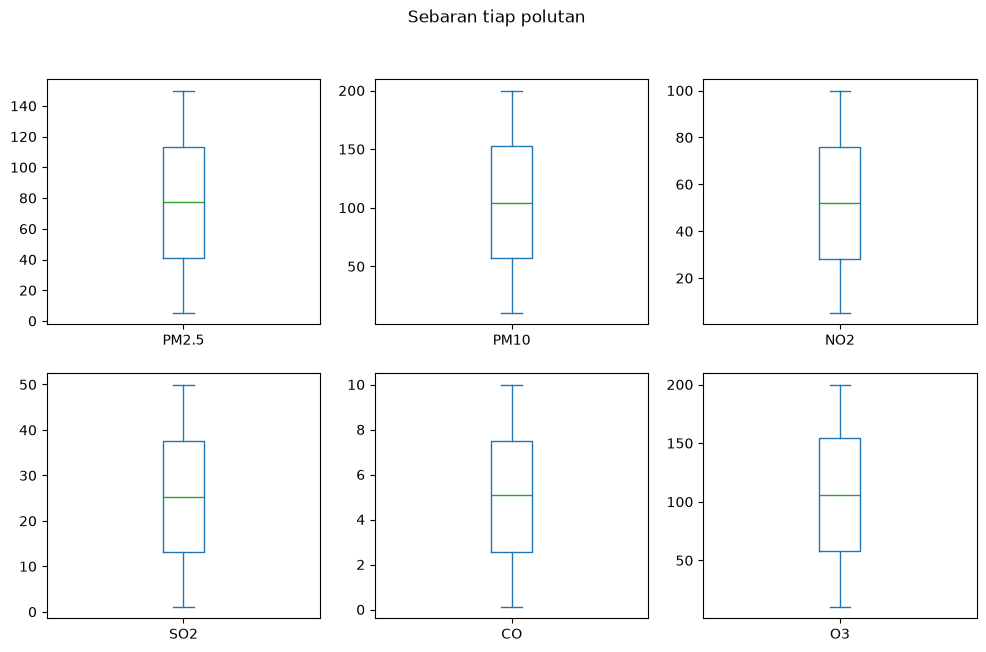

In [42]:
df[polutan].plot(kind="box", subplots=True, layout=(2, 3), figsize=(12, 7), title="Sebaran Tiap Polutan");


**Kesimpulan**

1. Rata-rata PM2.5 hampir sama di semua kota, sekitar 74,69 µg/m³ (Paris) sampai 80,01 µg/m³ (Dubai), selisih hanya sekitar 5 µg/m³. Mediannya berkisar 71,44 (Madrid) sampai 83,81 (Tokyo). Standar deviasinya besar, sekitar 40-43 di setiap kota. Artinya variasi harian di dalam satu kota jauh lebih besar daripada perbedaan antar kota, sehingga tidak ada kota yang benar-benar menonjol lebih tercemar.
   
2. Dugaan bahwa kota dengan kelembapan tinggi memiliki PM10 dan NO2 lebih rendah tidak terbukti.

| Kategori kelembapan | Rata-rata PM10 | Rata-rata NO2 |
|:---|---:|---:|
| Rendah | 104,39 | 52,12 |
| Tinggi | 104,46 | 52,25 |

    Selisihnya nyaris nol, dan korelasi tingkat baris juga hampir nol (Humidity-PM10 = 0,006; Humidity-NO2 = 0,001). Jadi kelembapan tidak berpengaruh berarti terhadap kadar PM10 maupun NO2 dalam data ini.

3. Berdasarkan std dan range mentah, PM10 dan O3 tampak paling bervariasi (std sekitar 55 dan range sekitar 190). Namun itu karena skala nilainya memang lebih besar. Perbandingan yang adil memakai koefisien variasi (CV):

| Polutan | CV (%) |
|---|---|
| CO | 56,51 |
| SO2 | 55,60 |
| PM2.5 | 54,14 |
| PM10 | 52,72 |
| NO2 | 52,34 |
| O3 | 51,95 |

    CO paling bervariasi dan O3 paling stabil, tetapi selisih antar polutan sangat kecil (sekitar 52-57%).


    Pola yang serba mirip antar kota dan korelasi yang hampir nol menunjukkan bahwa data ini kemungkinan besar sintetis (nilai tersebar merata dalam rentang tetap). Karena itu hasilnya tidak mencerminkan kondisi kualitas udara yang sebenarnya di kota-kota tersebut.

In [2]:
#contoh